In [ ]:
import pandas as pd
import os
import polars as pl
import joblib
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
import math
import matplotlib.gridspec as gridspec
import mplhep as hep
from scipy import stats
from scipy.stats import chi2
import pyBumpHunter as BH
import seaborn as sns
from scipy.interpolate import griddata
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

hep.style.use(hep.style.ROOT)

helpers_path = os.path.join('/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

## SETTINGS and LOADING EVENTS

In [8]:
selection = "ATLAS"
LUMI = 25.3845 # fb^-1
N_GEN_SIG = 100_000

SIGNAL_DIR = "/home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2"
SCALER_PATH = f"Final_Dataset_{selection}/minmax_scaler.joblib"
MODELS_DIR = f"Eval_CWoLa_SR_{selection}_ver2/"
model_path = f"Models_Extrapolation_{selection}_ver2"

METADATA_LIST = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
]
DF_META = pd.DataFrame(METADATA_LIST)

DEVICE = "cpu"
N_ENSEMBLE = 10
context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

scaler = joblib.load(SCALER_PATH)
device = torch.device("cpu")

SIGNAL_MODES = ["1000_2", "1000_4", "1000_6", "1000_8", "2000_2", "2000_4", "2000_6", "2000_8", "3000_2", "3000_4", "3000_6", "3000_8"]

In [9]:
def load_signal(mode_str, detector_mode,  base_path=SIGNAL_DIR):

    file_path = os.path.join(base_path, "SR", f"bsm_{mode_str}_{detector_mode}.parquet")
    if not os.path.exists(file_path):
        print(f"Error: Signal file {file_path} not found.")
        return None

    sig_pre_cols = [
        "tau21_j1", "tau32_j1", "tau21_j2", "tau32_j2", 
        "ht", "met_recalc_pt", "mjj"
    ]
    df_sim = pd.read_parquet(file_path, columns=sig_pre_cols)
    row = DF_META[(DF_META['Mass'] == int(mode_str.split("_")[0])) & (DF_META['Rinv'] == int(mode_str.split("_")[1]))]
    xs_eff, theory_unc = row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']
    norm_factor = (xs_eff * LUMI) / N_GEN_SIG

    df_sim['weight'] = norm_factor
    
    rename_mapping = {
        "m_jj": "mjj",
        "tau21_j1": "ljet1_tau21",
        "tau32_j1": "ljet1_tau32",
        "tau21_j2": "ljet2_tau21",
        "tau32_j2": "ljet2_tau32",
        "met": "met_recalc_pt",
        "weight": "final_weight"
    }
    df_sim = df_sim.rename(columns=rename_mapping)
    
    return df_sim


In [10]:
def apply_sr_cuts(df):
    return df[
        (df["ht"] > 600) & 
        (df["met_recalc_pt"] > 600) & 
        (df["met_recalc_pt"] < 2000) & 
        (df["mjj"] < 10000) & 
        (df["ht"] < 4000)
    ]

def transform(df, scale=True):
    # 1. Create a copy immediately so the original remains untouched
    df_transformed = df.copy()
    
    # Order of the variables 
    features_to_scale = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    # 2. Apply transformations to the COPY
    if scale:
        df_transformed.loc[:, features_to_scale] = scaler.transform(df_transformed[features_to_scale].values).astype('float32')
    else:
        df_transformed.loc[:, features_to_scale] = scaler.inverse_transform(df_transformed[features_to_scale].values).astype('float32')
        
    # 3. Return the modified copy
    return df_transformed

def score_BSM(df, bkg_type, k = 5):
    features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

    sig_events_to_score = df[features_vars].values

    all_scores = []
    for i in range(k):
        model_name = f"model_Data_vs_{bkg_type}_ATLAS_fold{i + 1}.pt"
        NN = torch.load(f"{MODELS_DIR}/kfold/{model_name}", map_location=DEVICE, weights_only=False)
        NN.model.eval()

        scores_sig = NN.evaluation(sig_events_to_score).flatten()
        all_scores.append(scores_sig)

    df[f"bsm_score_{bkg_type}"] = np.median(all_scores, axis = 0)
    return df


def process_bsm_signal(sig_id, mode):
    """Loads and processes a single signal dataset."""
    df = load_signal(sig_id, mode)
    df = apply_sr_cuts(df)
    df = transform(df)
    df = score_BSM(df, "Nom")
    df = score_BSM(df, "Reweight_Median")
    df = score_BSM(df, "Generate_Combined")
    return df

In [11]:
# Load SR Data and Background (Nomnial, Reweight, and Generate)

df_data = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/DATA_SR_scored.parquet")
df_mc_rw = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_reweighted_scored.parquet")
nominal_w = df_mc_rw["final_weight"].values
rw_ensemble_weights = [df_mc_rw[f'reweight_weights_ens{i}'].values for i in range(N_ENSEMBLE)]
rw_median = np.median(rw_ensemble_weights, axis=0)
df_mc_rw["rw_mediam_weights"] = nominal_w * rw_median

gen_dfs = []
for i in range(N_ENSEMBLE):
    # Note: enumerate started at 0 in your saving script, so it's ens0 to ens4
    df = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_Generate_ens{i}_scored.parquet")
    
    # Scale the weights directly in the dataframe
    df['total_weight'] = df['total_weight'] / 10
    
    gen_dfs.append(df)
df_mc_gen = pd.concat(gen_dfs, ignore_index=True)

# Invert Scores since I mistakenly trained data to be 0 and background to be 1, but I want the opposite. So, I will invert the scores here.
df_data['score_vs_nominal'] = 1.0 - df_data['score_vs_nominal']
df_data['score_vs_reweighted'] = 1.0 - df_data['score_vs_reweighted']
df_data['score_vs_generate'] = 1.0 - df_data['score_vs_generate']

df_mc_rw['score_vs_data'] = 1.0 - df_mc_rw['score_vs_data']
df_mc_rw['score_vs_reweighted_data'] = 1.0 - df_mc_rw['score_vs_reweighted_data']

df_mc_gen['score_vs_data'] = 1.0 - df_mc_gen['score_vs_data']

In [12]:
detector_modes = ["default", "pu", "run2", "pu_run2"]
sig_dfs = {mode: {} for mode in detector_modes}

for mode in detector_modes:
    for sig_id in SIGNAL_MODES:
        # This runs your pipeline and stores it perfectly organized
        sig_dfs[mode][sig_id] = process_bsm_signal(sig_id, mode)

detector_type = "default" # default, pu, run2, pu_run2
df_sig_def = sig_dfs[detector_type]

# Invert Scores for Signal DataFrames
for sig_id in SIGNAL_MODES:
    df_sig_def[sig_id]['bsm_score_Nom'] = 1.0 - df_sig_def[sig_id]['bsm_score_Nom']
    df_sig_def[sig_id]['bsm_score_Reweight_Median'] = 1.0 - df_sig_def[sig_id]['bsm_score_Reweight_Median']
    df_sig_def[sig_id]['bsm_score_Generate_Combined'] = 1.0 - df_sig_def[sig_id]['bsm_score_Generate_Combined']

In [13]:
# Unscale back to physical values for analysis
df_data_unscaled = transform(df_data, scale=False)
df_mc_rw_unscaled = transform(df_mc_rw, scale=False)
df_mc_gen_unscaled = transform(df_mc_gen, scale=False)

df_sig_def_unscaled = {}

for sig_id in SIGNAL_MODES:
    df_sig_def_unscaled[sig_id] = transform(df_sig_def[sig_id], scale=False)

## Phase 1 (Background Only)

In [14]:
def apply_hybrid_cut(df_data, df_bkg, bkg_type, target_eff=0.01):
    """
    Finds the NN score threshold for the top X% of background and cuts both datasets.
    Uses predefined column configurations based on bkg_type ('NOM', 'RW', or 'GEN').
    """
    
    # 1. Map column names based on background type
    if bkg_type == "NOM":
        data_score_col = "score_vs_nominal"
        bkg_score_col = "score_vs_data"
        weight_col = "final_weight"
    elif bkg_type == "RW":
        data_score_col = "score_vs_reweighted"
        bkg_score_col = "score_vs_reweighted_data"
        weight_col = "rw_mediam_weights"
    elif bkg_type == "GEN":
        data_score_col = "score_vs_generate"
        bkg_score_col = "score_vs_data"
        weight_col = "total_weight"
    else:
        raise ValueError("bkg_type must be 'NOM', 'RW', or 'GEN'")

    # 2. Extract scores and weights
    bkg_scores = df_bkg[bkg_score_col].values
    bkg_weights = df_bkg[weight_col].values

    # 3. Sort to find the exact threshold based on weights
    sort_idx = np.argsort(bkg_scores)
    sorted_scores = bkg_scores[sort_idx]
    sorted_weights = np.abs(bkg_weights[sort_idx])
    
    cum_weights = np.cumsum(sorted_weights)
    if cum_weights[-1] == 0:
        raise ValueError("Total background weight is zero. Cannot compute threshold.")
        
    cum_weights_norm = cum_weights / cum_weights[-1]

    # 4. Find threshold for the target efficiency
    threshold_idx = np.searchsorted(cum_weights_norm, 1.0 - target_eff)
    
    # Protect against out-of-bounds index
    if threshold_idx >= len(sorted_scores):
        threshold_idx = len(sorted_scores) - 1
        
    threshold = sorted_scores[threshold_idx]
    
    print(f"--- {bkg_type} Cut ---")
    print(f"Applying cut at NN Score > {threshold:.4f} (Top {target_eff*100:.1f}% Background)")

    # 5. Filter and return new datasets
    data_sr = df_data[df_data[data_score_col] > threshold].copy()
    bkg_sr = df_bkg[df_bkg[bkg_score_col] > threshold].copy()
    
    return data_sr, bkg_sr, threshold

In [15]:
# Check inclusive pre-cut yields in the Signal Region
total_data_pre_cut = len(df_data_unscaled)
total_gen_pre_cut = df_mc_gen_unscaled['total_weight'].sum()
total_rw_pre_cut = df_mc_rw_unscaled['rw_mediam_weights'].sum()
total_nom_pre_cut = df_mc_rw_unscaled['final_weight'].sum()

print("="*20,"Pre-Cut Yields in Signal Region:", "="*20)

print(f"Pre-Cut Data Yield: {total_data_pre_cut}")
print(f"Pre-Cut GEN Yield:  {total_gen_pre_cut:.2f}")
print(f"Pre-Cut RW Yield:   {total_rw_pre_cut:.2f}")
print(f"Pre-Cut NOM Yield:  {total_nom_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/GEN):      {total_data_pre_cut / total_gen_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/RW):       {total_data_pre_cut / total_rw_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/NOM):      {total_data_pre_cut / total_nom_pre_cut:.2f}")


print("="*20,"Post-Cut Yields in Signal Region:", "="*20)
post_cut_data_nom, post_cut_nom, nom_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="NOM", target_eff=0.01)
post_cut_data_rw, post_cut_rw, rw_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="RW", target_eff=0.01)
post_cut_data_gen, post_cut_gen, gen_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_gen_unscaled, bkg_type="GEN", target_eff=0.01)

print()
print(f"Post-Cut Data Yield (NOM): {len(post_cut_data_nom)}")
print(f"Post-Cut Data Yield (RW): {len(post_cut_data_rw)}")
print(f"Post-Cut Data Yield (GEN): {len(post_cut_data_gen)}")
print(f"Post-Cut NOM Yield: {post_cut_nom['final_weight'].sum():.2f}")
print(f"Post-Cut RW Yield: {post_cut_rw['rw_mediam_weights'].sum():.2f}")
print(f"Post-Cut GEN Yield: {post_cut_gen['total_weight'].sum():.2f}")
print(f"Post-Cut Ratio (Data/NOM): {len(post_cut_data_nom) / post_cut_nom['final_weight'].sum():.2f}")
print(f"Post-Cut Ratio (Data/RW): {len(post_cut_data_rw) / post_cut_rw['rw_mediam_weights'].sum():.2f}")
print(f"Post-Cut Ratio (Data/GEN): {len(post_cut_data_gen) / post_cut_gen['total_weight'].sum():.2f}")

==================== Pre-Cut Yields in Signal Region: ====================
Pre-Cut Data Yield: 188757
Pre-Cut GEN Yield:  183843.73
Pre-Cut RW Yield:   183495.26
Pre-Cut NOM Yield:  185438.64
Pre-Cut Ratio (Data/GEN):      1.03
Pre-Cut Ratio (Data/RW):       1.03
Pre-Cut Ratio (Data/NOM):      1.02
==================== Post-Cut Yields in Signal Region: ====================
--- NOM Cut ---
Applying cut at NN Score > 0.5832 (Top 1.0% Background)
--- RW Cut ---
Applying cut at NN Score > 0.5481 (Top 1.0% Background)
--- GEN Cut ---
Applying cut at NN Score > 0.5548 (Top 1.0% Background)

Post-Cut Data Yield (NOM): 2659
Post-Cut Data Yield (RW): 2250
Post-Cut Data Yield (GEN): 5014
Post-Cut NOM Yield: 1850.58
Post-Cut RW Yield: 1795.42
Post-Cut GEN Yield: 1834.40
Post-Cut Ratio (Data/NOM): 1.44
Post-Cut Ratio (Data/RW): 1.25
Post-Cut Ratio (Data/GEN): 2.73


### CHECK BACKGROUND MODELLING

In [16]:
def plot_corr_diff(corr_data, corr_bkg, corr_diff, bkg_type):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cmap = 'coolwarm'
    labels = [r'$m_{jj}$', r'Jet 1 $\tau_{21}$', r'Jet 1 $\tau_{32}$', r'Jet 2 $\tau_{21}$', r'Jet 2 $\tau_{32}$']

    # 1. Data Correlation
    sns.heatmap(corr_data, ax=axes[0], annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1, 
            xticklabels=labels, yticklabels=labels)
    axes[0].set_title("Data (Top 1% NN Score)", fontsize=14)

    sns.heatmap(corr_bkg, ax=axes[1], annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1, 
            xticklabels=labels, yticklabels=labels)
    axes[1].set_title(f"{bkg_type} Model (Top 1% NN Score)", fontsize=14)


    # A perfect generator would have all 0s here.
    sns.heatmap(corr_diff, ax=axes[2], annot=True, fmt=".2f", cmap="PiYG", vmin=-0.5, vmax=0.5, 
            xticklabels=labels, yticklabels=labels)
    axes[2].set_title(f"Difference (Data - {bkg_type})", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()


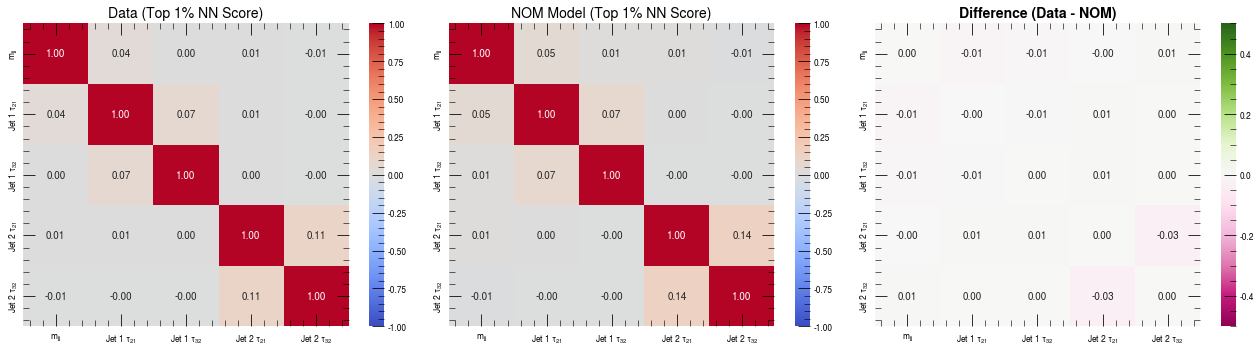

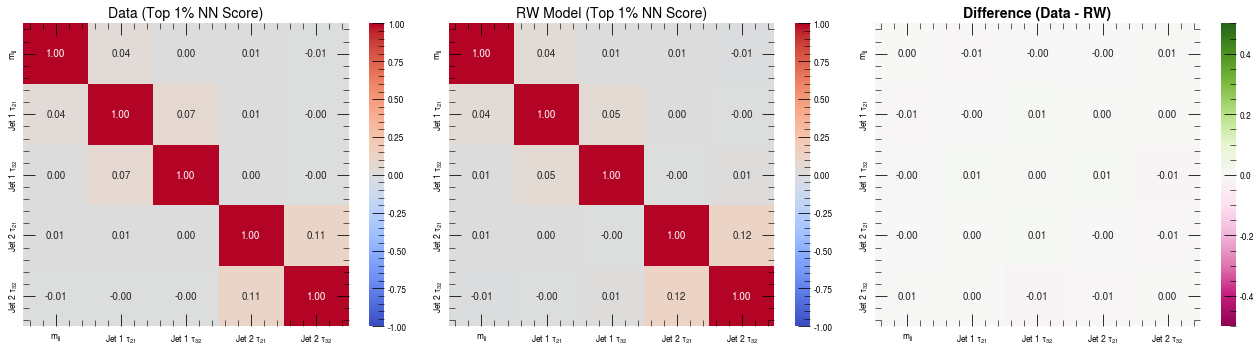

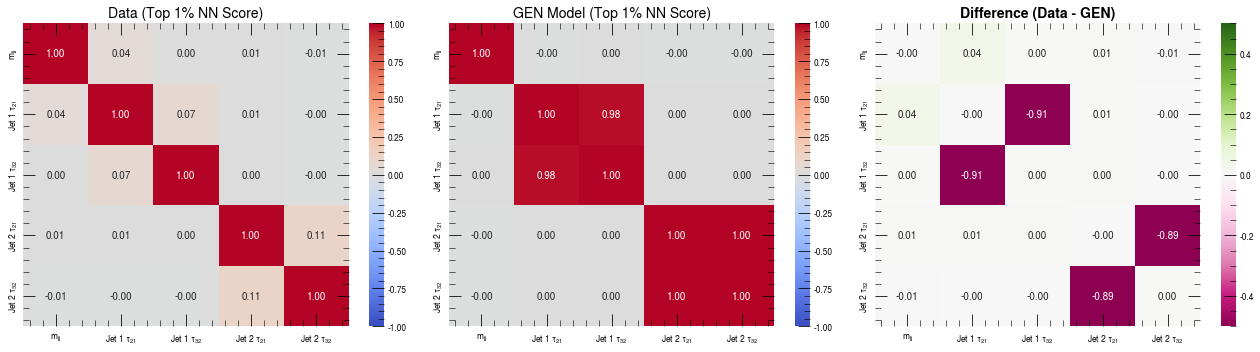

In [17]:
def get_weighted_correlation(df, features, weight_col):
    """Calculates the weighted Pearson correlation matrix."""
    # Extract arrays
    X = df[features].values
    w = df[weight_col].values
    w = np.abs(w)  # Ensure weights are non-negative
    # Calculate weighted covariance matrix (rowvar=False means columns are variables)
    cov_matrix = np.cov(X, rowvar=False, aweights=w)
    
    # Convert covariance to correlation matrix
    std_devs = np.sqrt(np.diag(cov_matrix))
    corr_matrix = cov_matrix / np.outer(std_devs, std_devs)
    
    return corr_matrix


features_list = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

# For Data, assume weight is 1.0 for all events if unweighted
if 'weight' not in df_data_unscaled.columns:
    df_data_unscaled['weight'] = 1.0

corr_data = get_weighted_correlation(df_data_unscaled, features_list, 'weight')
corr_nom = get_weighted_correlation(df_mc_rw_unscaled, features_list, 'final_weight')
corr_gen = get_weighted_correlation(df_mc_gen_unscaled, features_list, 'total_weight')
corr_rw = get_weighted_correlation(df_mc_rw_unscaled, features_list, 'rw_mediam_weights')

# The most important metric: where did the flow fail?
corr_diff_nom = corr_data - corr_nom
corr_diff_rw = corr_data - corr_rw
corr_diff_gen = corr_data - corr_gen


plot_corr_diff(corr_data, corr_nom, corr_diff_nom, bkg_type="NOM")
plot_corr_diff(corr_data, corr_rw, corr_diff_rw, bkg_type="RW")
plot_corr_diff(corr_data, corr_gen, corr_diff_gen, bkg_type="GEN")

GEN Background modelling has some issues in generating the $\tau_{21}$ and $\tau_{32}$ variables. Therefore only RW Background modelling will be used for the background only hypothesis

### NULL HYPOTHESIS TESTING

Statistical Variance ($\sigma_{\text{stat}, i}^2$)
$$\sigma_{\text{stat}, i}^2 = \sum_{k \in \text{bin } i} (w_{k})^2$$

ML Epistemic Systematic Variance ($\sigma_{\text{sys}, i}^2$) with a flat 5% ($0.05$) closure error derived from the control region.
$$B_{i, j} = \sum_{k \in \text{bin } i} \left( w_{\text{nominal}, k} \times \text{ens}_{j, k} \right)$$
$$\sigma_{\text{sys}, i} = B_i \times \sqrt{ \left( \frac{\sigma_{\text{ens}, i}}{B_i} \right)^2 + 0.05^2 }$$

In [ ]:
# =====================================================================
# 1. SETUP & BINS
# =====================================================================
mjj_bins = np.concatenate([
    np.arange(400, 1000, 50), 
    np.arange(1000, 2000, 100), 
    np.arange(2000, 4200, 200)
])
n_bins = len(mjj_bins) - 1

# Calculate Data (N) and Reweighted Background (B) yields
N, _ = np.histogram(post_cut_data_rw['mjj'].values, bins=mjj_bins)
B, _ = np.histogram(post_cut_rw['mjj'].values, bins=mjj_bins, weights=post_cut_rw['rw_mediam_weights'].values)

# =====================================================================
# 2. STATISTICAL VARIANCE (UNCORRELATED)
# =====================================================================
# MC Statistical Error per bin (Sum of squared weights)
var_stat = np.histogram(
    post_cut_rw['mjj'].values, 
    bins=mjj_bins, 
    weights=post_cut_rw['rw_mediam_weights'].values**2
)[0]

# =====================================================================
# 3. MACHINE LEARNING (RW MODEL) SYSTEMATICS
# =====================================================================
# A. ML Epistemic Model Spread across 10 Ensemble Folds
ensemble_yields = np.zeros((10, n_bins))
for i in range(10):
    w_ens = post_cut_rw['final_weight'].values * post_cut_rw[f'reweight_weights_ens{i}'].values
    counts, _ = np.histogram(post_cut_rw['mjj'].values, bins=mjj_bins, weights=w_ens)
    ensemble_yields[i, :] = counts

ensemble_std = np.std(ensemble_yields, axis=0)
sys_ml_spread_frac = np.divide(ensemble_std, B, out=np.zeros_like(ensemble_std), where=B!=0)

# B. ML Non-Closure Error (Derived from CR validation AUC residual ~ 2.5% to 5%)
closure_err_frac = 0.05 

# Combine ML uncertainties (Spread + Non-Closure)
total_ml_err_frac = np.sqrt(sys_ml_spread_frac**2 + closure_err_frac**2)
std_ml_sys = total_ml_err_frac * B

# =====================================================================
# 4. EXPERIMENTAL & PHYSICS SYSTEMATICS (LUMI, JES, JER, THEORY)
# =====================================================================
# A. Luminosity Uncertainty
# Standard ATLAS Run-2 per-year/partial luminosity error is ~1.7% to 2.1% (To be conservative I use 5%)
lumi_err_frac = 0.05
std_lumi_sys = lumi_err_frac * B

# B. Jet Energy Scale (JES) & Jet Energy Resolution (JER)
# JES/JER causes shape distortions in the steeply falling mass spectrum.
# Modeled as a mass-dependent envelope: 3% at 400 GeV up to 15% at 4000 GeV
min_mass, max_mass = 400.0, 4000.0
min_jes_err, max_jes_err = 0.03, 0.15

std_jes_jer_sys = np.zeros(n_bins)
for i in range(n_bins):
    bin_center = (mjj_bins[i] + mjj_bins[i+1]) / 2.0
    jes_frac = min_jes_err + (max_jes_err - min_jes_err) * ((bin_center - min_mass) / (max_mass - min_mass))
    std_jes_jer_sys[i] = jes_frac * B[i]

# C. Theoretical PDF & Scale (\mu_R, \mu_F) Uncertainties
# Mass-dependent theoretical envelope: 5% at 400 GeV up to 20% at 4000 GeV
min_theory_err, max_theory_err = 0.05, 0.20

std_theory_sys = np.zeros(n_bins)
for i in range(n_bins):
    bin_center = (mjj_bins[i] + mjj_bins[i+1]) / 2.0
    theory_frac = min_theory_err + (max_theory_err - min_theory_err) * ((bin_center - min_mass) / (max_mass - min_mass))
    std_theory_sys[i] = theory_frac * B[i]

# =====================================================================
# 5. COMBINE ALL SYSTEMATIC STANDARD DEVIATIONS (PER BIN)
# =====================================================================
# Add independent systematic components in quadrature per bin
std_sys_total = np.sqrt(
    std_ml_sys**2 + 
    std_lumi_sys**2 + 
    std_jes_jer_sys**2 + 
    std_theory_sys**2
)

# Total Systematic Variance per bin
var_sys_total = std_sys_total**2

# =====================================================================
# 6. BUMPHUNTER SCAN
# =====================================================================
print(f"Surviving Data events: {N.sum():.0f}")
print(f"Surviving Bkg expected events: {B.sum():.2f}")

hunter = BH.BumpHunter1D(
    rang=[400, 4000],      
    width_min=2,           
    width_max=15,          
    width_step=1,          
    scan_step=1,           
    npe=10000,             
    nworker=4,             
    seed=42,               
    use_sideband=False     
)

print("Running pyBumpHunter scan...")
hunter.bump_scan(data=N, bkg=B, is_hist=True)

# =====================================================================
# 7. FINAL TEST STATISTIC (Z) WITH CORRELATED WINDOW SYSTEMATICS
# =====================================================================
print("\n--- Final Null Hypothesis Test ---")

if hasattr(hunter, 'min_loc_ar') and len(hunter.min_loc_ar) > 0:
    bump_start_idx = hunter.min_loc_ar[0]
    bump_end_idx = hunter.min_loc_ar[1]
    
    bump_start_mass = mjj_bins[bump_start_idx]
    bump_end_mass = mjj_bins[bump_end_idx + 1]
    
    print(f"Most significant mass window: {bump_start_mass:.1f} - {bump_end_mass:.1f} GeV")
    
    # 1. Window Yields
    obs_data = np.sum(N[bump_start_idx : bump_end_idx + 1])
    exp_bkg = np.sum(B[bump_start_idx : bump_end_idx + 1])
    
    # 2a. MC Stat Variance (Uncorrelated across bins: Sum of Variances)
    window_var_stat = np.sum(var_stat[bump_start_idx : bump_end_idx + 1])
    
    # 2b. Systematic Variance (Correlated across bins: Sum of Std Devs, then Squared)
    window_std_sys = np.sum(std_sys_total[bump_start_idx : bump_end_idx + 1])
    window_var_sys = window_std_sys**2
    
    # 3. Total Variance Equation: B + Var_stat + Var_sys_correlated
    total_variance = exp_bkg + window_var_stat + window_var_sys
    
    # 4. Significance Calculation (Z)
    if total_variance > 0:
        sys_sig = (obs_data - exp_bkg) / np.sqrt(total_variance)
    else:
        sys_sig = 0.0
        
    print(f"Window Data Yield:        {obs_data:.0f}")
    print(f"Window Background Yield:  {exp_bkg:.2f} ± {np.sqrt(window_var_stat + window_var_sys):.2f} (Stat+Sys)")
    print(f"  - MC Stat Uncertainty:   ± {np.sqrt(window_var_stat):.2f}")
    print(f"  - Systematics Uncertainty: ± {window_std_sys:.2f}")
    print(f"Test Statistic (Local Z): {sys_sig:.2f} sigma")
    
    if sys_sig < 2.0:
        print("\nCONCLUSION: Fail to reject H0. The anomaly is absorbed by Systematics (Lumi, JES, ML, Theory).")
    else:
        print("\nCONCLUSION: Reject H0. The anomaly SURVIVES all systematics! Potential Discovery.")
else:
    print("No significant bumps found. Fail to reject H0.")

Surviving Data events: 1412
Surviving Bkg expected events: 1141.85
Running pyBumpHunter scan...
Generating histograms
14 values of width will be tested
SCAN


Global p-value : 0.0000  (0 / 10000)
Significance > 3.71902 (lower limit)


--- Final Null Hypothesis Test ---
Most significant mass window: 400.0 - 1600.0 GeV
Window Data Yield:        1114
Window Background Yield:  888.24 ± 98.08 (Stat+Sys)
  - MC Stat Uncertainty:   ± 27.88
  - Systematics Uncertainty: ± 94.04
Test Statistic (Local Z): 2.20 sigma

CONCLUSION: Reject H0. The anomaly SURVIVES all systematics! Potential Discovery.


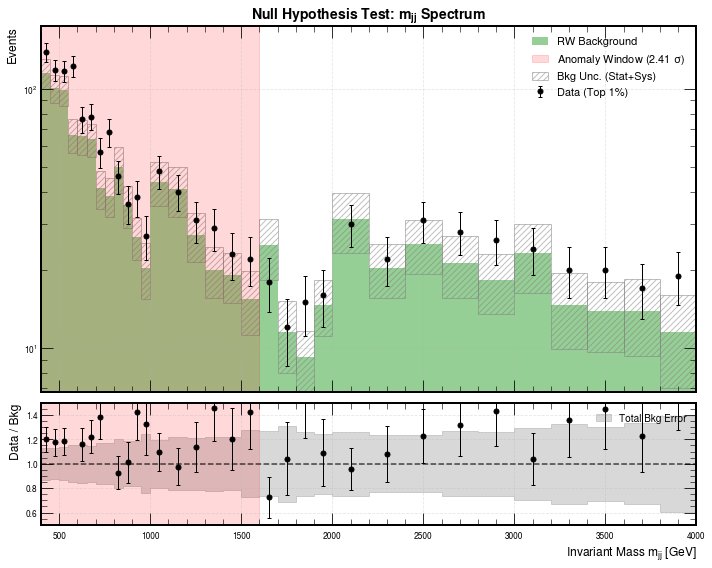

In [19]:
import matplotlib.pyplot as plt

# --- 1. PREPARE PLOTTING VARIABLES ---
bin_centers = (mjj_bins[:-1] + mjj_bins[1:]) / 2.0
bin_widths = np.diff(mjj_bins)

# Calculate total errors per bin
err_data = np.sqrt(N)
err_bkg_total = np.sqrt(var_stat + var_sys_total)

# Calculate ratios (safely avoiding division by zero)
ratio = np.divide(N, B, out=np.zeros_like(N, dtype=float), where=B!=0)
ratio_data_err = np.divide(err_data, B, out=np.zeros_like(err_data, dtype=float), where=B!=0)
ratio_bkg_err = np.divide(err_bkg_total, B, out=np.zeros_like(err_bkg_total, dtype=float), where=B!=0)

# --- 2. CREATE FIGURE & AXES ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(10, 8), 
    gridspec_kw={'height_ratios': [3, 1]}, 
    sharex=True
)

# --- 3. UPPER PANEL: MAIN SPECTRUM ---
# Background histogram
ax1.hist(mjj_bins[:-1], bins=mjj_bins, weights=B, color="#2ca02c", alpha=0.5, label="RW Background", histtype="stepfilled")

# Background total uncertainty band (Stat + Sys)
ax1.bar(
    bin_centers, 2 * err_bkg_total, bottom=B - err_bkg_total, 
    width=bin_widths, fill=False, hatch='////', edgecolor='gray', alpha=0.5, label="Bkg Unc. (Stat+Sys)"
)

# Data points
ax1.errorbar(
    bin_centers, N, yerr=err_data, 
    fmt='ko', label="Data (Top 1%)", capsize=2, elinewidth=1, markersize=5
)

# Highlight the BumpHunter anomaly window (400 to 1600 GeV)
ax1.axvspan(400, 1600, color='red', alpha=0.15, label="Anomaly Window (2.41 $\sigma$)")

# Formatting ax1
ax1.set_ylabel("Events", fontsize=12)
ax1.set_title(r"Null Hypothesis Test: $m_{jj}$ Spectrum", fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.set_xlim(mjj_bins[0], mjj_bins[-1])
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.3)

# --- 4. LOWER PANEL: RATIO PLOT ---
ax2.axhline(1.0, color='black', linestyle='--', alpha=0.7)

# Background fractional uncertainty band
ratio_bkg_band_upper = np.append(1 + ratio_bkg_err, (1 + ratio_bkg_err)[-1])
ratio_bkg_band_lower = np.append(1 - ratio_bkg_err, (1 - ratio_bkg_err)[-1])

ax2.fill_between(
    mjj_bins, ratio_bkg_band_lower, ratio_bkg_band_upper, 
    step='post', color='gray', alpha=0.3, label="Total Bkg Error"
)

# Highlight the same window in the ratio plot
ax2.axvspan(400, 1600, color='red', alpha=0.15)

# Data/Bkg points
ax2.errorbar(
    bin_centers, ratio, yerr=ratio_data_err, 
    fmt='ko', capsize=2, elinewidth=1, markersize=5
)

# Formatting ax2
ax2.set_xlabel(r"Invariant Mass $m_{jj}$ [GeV]", fontsize=12)
ax2.set_ylabel("Data / Bkg", fontsize=12)
ax2.set_ylim(0.5, 1.5) # Adjust this if the ratio spikes higher/lower
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Phase 2: BSM Signal

In [ ]:
h1_results = []

for sig_id in SIGNAL_MODES:
    df_sig = df_sig_def_unscaled[sig_id]
    
    # --- 1. APPLY THE SIGNAL REGION CUT ---
    # Apply the exact same 1% anomaly score threshold used for Data and Background
    sig_sr = df_sig[df_sig['bsm_score_Reweight_Median'] > rw_threshold]
    
    # --- 2. CALCULATE SIGNAL YIELDS & VARIANCE ---
    # Bin the surviving signal events into the same mjj_bins
    S_i, _ = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values)
    
    # Calculate the statistical variance of the signal (sum of squared weights)
    var_sig_stat_i = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values**2)[0]
    
    # If the signal is entirely killed by the anomaly cut, record 0 and skip
    if S_i.sum() <= 0:
        h1_results.append({
            "Model": sig_id, "Mass Window": "N/A", "Exp. B": 0, "Obs. Data": 0, 
            "Data Excess": 0, "Signal (S)": 0, "Exp. Z": 0.0, "Pull (H1)": np.nan
        })
        continue
        
    # --- 3. DYNAMICALLY DEFINE THE SIGNAL MASS WINDOW ---
    # A resonance is narrow. We find the bins where the signal yield is at least 
    # 5% of the peak signal bin to define the active signal window.
    active_bins = np.where(S_i > 0.05 * np.max(S_i))[0]
    start_idx = active_bins[0]
    end_idx = active_bins[-1]
    
    window_start_mass = mjj_bins[start_idx]
    window_end_mass = mjj_bins[end_idx + 1]
    
    # --- 4. EXTRACT YIELDS IN THE WINDOW ---
    S_win = np.sum(S_i[start_idx : end_idx + 1])
    B_win = np.sum(B[start_idx : end_idx + 1])
    N_win = np.sum(N[start_idx : end_idx + 1])
    
    # --- 5. EXTRACT & COMBINE VARIANCES IN THE WINDOW ---
    # Background variances (using the logic fixed in the previous steps)
    window_var_stat_bkg = np.sum(var_stat[start_idx : end_idx + 1])
    window_std_sys_bkg = np.sum(np.sqrt(var_sys_total[start_idx : end_idx + 1]))
    window_var_sys_bkg = window_std_sys_bkg**2  # Correlated squaring
    
    window_var_bkg = window_var_stat_bkg + window_var_sys_bkg
    
    # Signal statistical variance
    window_var_sig = np.sum(var_sig_stat_i[start_idx : end_idx + 1])
    
    # --- 6. CALCULATE HYPOTHESIS METRICS ---
    # Expected Significance (Sensitivity): S / sqrt(B + Var_B)
    Z_exp = S_win / np.sqrt(B_win + window_var_bkg) if (B_win + window_var_bkg) > 0 else 0
    
    # H1 Pull: (Data - (B + S)) / sqrt(B + S + Var_B + Var_S)
    # Note: B_win and S_win are included in the denominator as Poisson variance terms
    total_variance_H1 = B_win + S_win + window_var_bkg + window_var_sig
    pull_H1 = (N_win - (B_win + S_win)) / np.sqrt(total_variance_H1) if total_variance_H1 > 0 else 0
    
    # Data excess for contextual comparison
    excess_win = N_win - B_win
    
    # Append to results
    h1_results.append({
        "Model": sig_id,
        "Mass Window": f"{window_start_mass:.0f}-{window_end_mass:.0f}",
        "Exp. B": B_win,
        "Obs. Data": N_win,
        "Data Excess": excess_win,
        "Signal (S)": S_win,
        "Exp. Z": Z_exp,
        "Pull (H1)": pull_H1
    })

# --- 7. DISPLAY RESULTS ---
df_h1 = pd.DataFrame(h1_results)
print("\n--- Alternative Hypothesis (H1) Evaluation ---")
print(df_h1.to_string(index=False, float_format=lambda x: f"{x:.2f}" if isinstance(x, float) else x))


--- Alternative Hypothesis (H1) Evaluation ---
 Model Mass Window  Exp. B  Obs. Data  Data Excess  Signal (S)  Exp. Z  Pull (H1)
1000_2   1200-3600  310.01        367        56.99        9.70    0.17       0.82
1000_4    500-4000  926.52       1156       229.48       31.48    0.24       1.53
1000_6    600-3600  736.07        881       144.93       55.77    0.53       0.83
1000_8    450-3600 1001.53       1238       236.47       92.16    0.70       1.08
2000_2   1100-4000  376.33        443        66.67        2.04    0.03       0.93
2000_4    800-4000  552.35        638        85.65        5.07    0.06       0.89
2000_6    750-4000  590.88        706       115.12        8.31    0.09       1.13
2000_8    500-4000  926.52       1156       229.48        9.85    0.08       1.70
3000_2   1400-4000  288.19        343        54.81        0.06    0.00       0.95
3000_4    950-4000  440.50        518        77.50        0.23    0.00       1.00
3000_6    600-4000  761.42        917       155.58

In [21]:
# import pyhf
# import numpy as np
# import pandas as pd

# pyhf.set_backend("numpy")

# # --- 1. PREPARE THE SYSTEMATICS ARRAYS ---
# # We use the arrays we already built in the H0 step.
# # pyhf requires strict avoidance of 0-background bins for stability.
# valid_bins = B > 0

# B_valid = B[valid_bins]
# N_valid = N[valid_bins]
# err_stat_valid = np.sqrt(var_stat[valid_bins])  # Absolute stat error
# err_ml_valid = std_ml_sys[valid_bins]           # Absolute ML error

# # For correlated shape systematics (histosys), pyhf needs the absolute yields of the Up/Down shifts
# B_jes_up = B_valid + std_jes_jer_sys[valid_bins]
# B_jes_down = np.clip(B_valid - std_jes_jer_sys[valid_bins], a_min=1e-6, a_max=None)

# B_theory_up = B_valid + std_theory_sys[valid_bins]
# B_theory_down = np.clip(B_valid - std_theory_sys[valid_bins], a_min=1e-6, a_max=None)

# # List to store our rigorous pyhf results
# pyhf_results = []

# print("--- Running pyhf Profile Likelihood Fits for BSM Models ---")

# # --- 2. LOOP OVER SIGNALS & BUILD WORKSPACES ---
# for sig_id in SIGNAL_MODES:
#     df_sig = df_sig_def_unscaled[sig_id]
    
#     # Apply the exact 1% anomaly score threshold
#     sig_sr = df_sig[df_sig['bsm_score_Reweight_Median'] > rw_threshold]
    
#     # Calculate Signal Yield
#     S, _ = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values)
#     S_valid = S[valid_bins]
    
#     # Skip models entirely killed by the anomaly cut
#     if S_valid.sum() <= 1e-3:
#         pyhf_results.append({
#             "Model": sig_id, "Signal Yield": 0.0, 
#             "Best-fit Mu": np.nan, "Observed CLs": np.nan, "Expected CLs": np.nan
#         })
#         continue


#     # =====================================================================
#     # NEW: DYNAMIC MU SCAN CALCULATION
#     # =====================================================================
#     # Approximate the background variance using a simple Poisson sqrt(B)
#     approx_bkg_err = np.sqrt(B_valid.sum())
    
#     # Estimate the mu needed to hit a ~2 sigma excess
#     estimated_mu_limit = (2.0 * approx_bkg_err) / S_valid.sum()
    
#     # Set the max scan range to 3 times the estimate to give pyhf plenty of room.
#     # We clip it between 5.0 (for strong signals) and 200.0 (for impossibly weak signals).
#     mu_max = float(np.clip(estimated_mu_limit * 3.0, a_min=5.0, a_max=None))
    
#     # Create 51 points just within our custom, targeted range
#     scan_mu = np.linspace(0.0, mu_max, 51)
#     # =====================================================================


#     # --- 3. CONSTRUCT THE PYHF WORKSPACE ---
#     # This translates our arrays and uncertainties into a formal statistical model
#     workspace_dict = {
#         "channels": [
#             {
#                 "name": "signal_region",
#                 "samples": [
#                     {
#                         "name": "background",
#                         "data": B_valid.tolist(),
#                         "modifiers": [
#                             # 1. MC Statistical Error
#                             {"name": "staterror", "type": "staterror", "data": err_stat_valid.tolist()},
#                             # 2. Luminosity (1.7% normalization uncertainty)
#                             {"name": "lumi", "type": "normsys", "data": {"hi": 1.017, "lo": 0.983}},
#                             # 3. JES/JER (Correlated Shape uncertainty)
#                             {"name": "jes_jer", "type": "histosys", "data": {"hi_data": B_jes_up.tolist(), "lo_data": B_jes_down.tolist()}},
#                             # 4. Theory PDF/Scale (Correlated Shape uncertainty)
#                             {"name": "theory", "type": "histosys", "data": {"hi_data": B_theory_up.tolist(), "lo_data": B_theory_down.tolist()}},
#                             # 5. ML Epistemic Spread + Non-Closure (Uncorrelated bin-by-bin shape uncertainty)
#                             {"name": "ml_systematics", "type": "shapesys", "data": err_ml_valid.tolist()}
#                         ]
#                     },
#                     {
#                         "name": "signal",
#                         "data": S_valid.tolist(),
#                         "modifiers": [
#                             # The Parameter of Interest (POI)
#                             {"name": "mu", "type": "normfactor", "data": None}
#                         ]
#                     }
#                 ]
#             }
#         ],
#         "observations": [
#             {"name": "signal_region", "data": N_valid.tolist()}
#         ],
#         "measurements": [
#             {
#                 "name": "Measurement", 
#                 "config": {
#                     "poi": "mu", 
#                     "parameters": [
#                         {
#                             "name": "mu",
#                             "bounds": [[0.0, float(mu_max * 1.2)]]
#                         }
#                     ]
#                 }
#             }
#         ],
#         "version": "1.0.0"
#     }
    
#     # Build the model and data array (combining observations + auxiliary constraint data)
#     workspace = pyhf.Workspace(workspace_dict)
#     model = workspace.model()
#     data = workspace.data(model)
    
#     # # --- 4. PERFORM THE FITS ---
#     # try:
#     #     # A. Find the Best-Fit Signal Strength (mu_hat)
#     #     # This profiles the nuisance parameters to find what amount of signal the data actually prefers
#     #     best_fit_pars = pyhf.infer.mle.fit(data, model)
#     #     mu_hat = best_fit_pars[model.config.poi_index]
        
#     #     # B. Hypothesis Test for mu = 1.0 (Testing the nominal BSM cross-section)
#     #     # This calculates the CLs limit. If CLs < 0.05, the model is excluded at 95% CL.
#     #     obs_limit, exp_limits = pyhf.infer.hypotest(
#     #         1.0, data, model, test_stat="qtilde", return_expected_set=True
#     #     )
        
#     #     # The expected limit is typically returned as a band [-2sigma, -1sigma, median, +1sigma, +2sigma]
#     #     exp_limit_median = exp_limits[2]
        
#     #     pyhf_results.append({
#     #         "Model": sig_id,
#     #         "Signal Yield": S_valid.sum(),
#     #         "Best-fit Mu (mu_hat)": mu_hat,
#     #         "Observed CLs": obs_limit,
#     #         "Expected CLs": exp_limit_median
#     #     })
        
#     # except Exception as e:
#     #     print(f"Fit failed for {sig_id}: {e}")
#     #     pyhf_results.append({
#     #         "Model": sig_id, "Signal Yield": S_valid.sum(), 
#     #         "Best-fit Mu (mu_hat)": np.nan, "Observed CLs": np.nan, "Expected CLs": np.nan
#     #     })

#     # try:
#     # A. Find the Best-Fit Signal Strength (mu_hat)
#     best_fit_pars = pyhf.infer.mle.fit(data, model)
#     mu_hat = best_fit_pars[model.config.poi_index]
    
#     # B. Hypothesis Test / Upper Limit Calculation
#     # Increased the scan range to mu=20 to catch weaker signals
#     # scan_mu = np.linspace(0, 100, 101) 
    
#     obs_limit, exp_limits, details= pyhf.infer.intervals.upper_limits.upper_limit(
#         data, 
#         model, 
#         scan_mu, 
#         level=0.05, 
#         return_results=True
#     )
    
#     try:
#         # C. Safely extract ALL the expected limit bands
#         if isinstance(exp_limits, (list, tuple, np.ndarray)) and len(exp_limits) >= 5:
#             exp_m2  = float(np.asarray(exp_limits)[0]) # -2 sigma
#             exp_m1  = float(np.asarray(exp_limits)[1]) # -1 sigma
#             exp_med = float(np.asarray(exp_limits)[2]) # Median
#             exp_p1  = float(np.asarray(exp_limits)[3]) # +1 sigma
#             exp_p2  = float(np.asarray(exp_limits)[4]) # +2 sigma
#         else:
#             exp_m2 = exp_m1 = exp_med = exp_p1 = exp_p2 = np.nan
            
#         # D. Safely extract the observed limit
#         try:
#             obs_limit = float(np.asarray(obs_limit))
#         except (TypeError, ValueError):
#             obs_limit = np.nan
        
#         pyhf_results.append({
#             "Model": sig_id,
#             "Signal Yield": S_valid.sum(),
#             "Best-fit Mu": mu_hat,
#             "Obs_Limit": obs_limit,
#             "Exp_m2": exp_m2,
#             "Exp_m1": exp_m1,
#             "Exp_med": exp_med,
#             "Exp_p1": exp_p1,
#             "Exp_p2": exp_p2
#         })
#     except Exception as e:
#         print(f"Fit failed for {sig_id}: {e}")
#         pyhf_results.append({
#             "Model": sig_id, "Signal Yield": S_valid.sum(), 
#             "Best-fit Mu": np.nan, "Obs_Limit": np.nan, "Exp_m2": np.nan, "Exp_m1": np.nan, "Exp_med": np.nan, "Exp_p1": np.nan, "Exp_p2": np.nan
#         })

# # --- 5. DISPLAY RESULTS ---
# df_pyhf = pd.DataFrame(pyhf_results)
# print("\n--- pyhf Profile Likelihood Results ---")
# print(df_pyhf.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x))

In [22]:
# df_pyhf.to_csv("pyhf_results.csv", index=False)

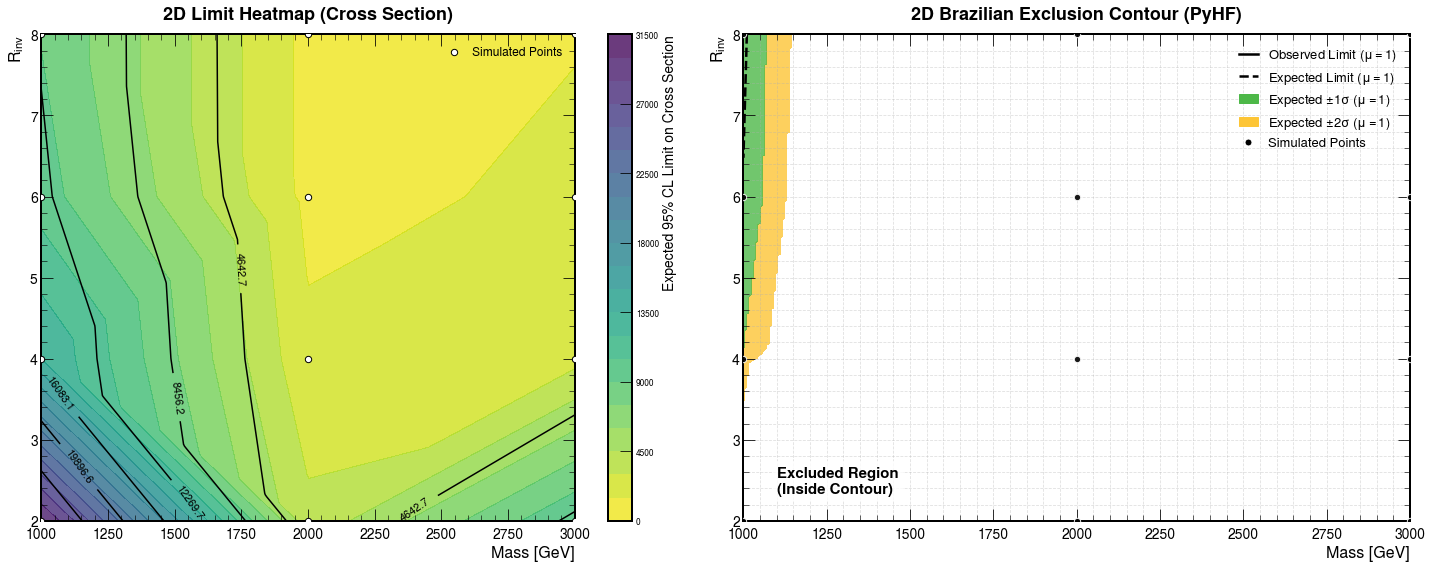

In [ ]:
def plot_2d_bsm_limits_corrected(df, 
                                 mass_col='Mass', 
                                 rinv_col='Rinv', 
                                 xs_col='XS',
                                 obs_col='Obs_Limit', 
                                 med_col='Exp_med',
                                 m1_col='Exp_m1', 
                                 p1_col='Exp_p1', 
                                 m2_col='Exp_m2', 
                                 p2_col='Exp_p2',
                                 exclusion_threshold=1.0,
                                 title_suffix="(PyHF)"):
    """
    Plots a 2D Heatmap (in Cross Section) and a 2D Brazilian Contour (in mu) side-by-side.
    """
    # Drop rows where limits or theoretical XS could not be found
    df_plot = df.dropna(subset=[med_col, obs_col, xs_col]).copy()
    
    x = df_plot[mass_col].values
    y = df_plot[rinv_col].values
    
    # Create the 2D Interpolation Grid (300x300 density)
    xi = np.linspace(x.min(), x.max(), 300)
    yi = np.linspace(y.min(), y.max(), 300)
    X, Y = np.meshgrid(xi, yi)
    
    # =====================================================================
    # INTERPOLATE FOR HEATMAP (CROSS SECTION)
    # =====================================================================
    # Multiply the mu limits by the theoretical cross section
    z_med_xs = df_plot[med_col].values * df_plot[xs_col].values
    z_obs_xs = df_plot[obs_col].values * df_plot[xs_col].values
    
    Z_med_XS = griddata((x, y), z_med_xs, (X, Y), method='linear')
    Z_obs_XS = griddata((x, y), z_obs_xs, (X, Y), method='linear')
    
    # =====================================================================
    # INTERPOLATE FOR BRAZILIAN CONTOUR (SIGNAL STRENGTH MU)
    # =====================================================================
    Z_obs = griddata((x, y), df_plot[obs_col].values, (X, Y), method='linear')
    Z_med = griddata((x, y), df_plot[med_col].values, (X, Y), method='linear')
    Z_m1  = griddata((x, y), df_plot[m1_col].values, (X, Y), method='linear')
    Z_p1  = griddata((x, y), df_plot[p1_col].values, (X, Y), method='linear')
    Z_m2  = griddata((x, y), df_plot[m2_col].values, (X, Y), method='linear')
    Z_p2  = griddata((x, y), df_plot[p2_col].values, (X, Y), method='linear')
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # =====================================================================
    # PLOT 1: 2D LIMIT HEATMAP (CROSS SECTION)
    # =====================================================================
    ax1 = axes[0]
    
    # Draw expected limit heatmap in XS
    cf1 = ax1.contourf(X, Y, Z_med_XS, cmap='viridis_r', levels=20, alpha=0.8)
    cbar = fig.colorbar(cf1, ax=ax1)
    cbar.set_label('Expected 95% CL Limit on Cross Section', fontsize=14)
    
    # Draw observed limit contours in XS
    try:
        if not np.isnan(Z_obs_XS).all():
            obs_levels = np.linspace(np.nanmin(Z_obs_XS), np.nanmax(Z_obs_XS), 8)
            cs1 = ax1.contour(X, Y, Z_obs_XS, colors='black', linestyles='solid', linewidths=1.5, levels=obs_levels)
            ax1.clabel(cs1, inline=True, fontsize=11, fmt='%1.1f')
    except Exception:
        pass
        
    ax1.scatter(x, y, color='white', edgecolor='black', s=40, zorder=5, label='Simulated Points')
    ax1.set_xlabel('Mass [GeV]', fontsize=16)
    ax1.set_ylabel(r'$R_{inv}$', fontsize=16)
    ax1.set_title(f'2D Limit Heatmap (Cross Section)', fontsize=18, fontweight='bold', pad=15)
    ax1.legend(loc='upper right', fontsize=12)
    ax1.tick_params(axis='both', labelsize=14)
    
    # =====================================================================
    # PLOT 2: 2D BRAZILIAN CONTOUR (SIGNAL STRENGTH MU)
    # =====================================================================
    ax2 = axes[1]
    
    band_grid = np.zeros_like(X)
    band_grid[(Z_m2 <= exclusion_threshold) & (Z_m1 > exclusion_threshold)] = 1
    band_grid[(Z_p1 <= exclusion_threshold) & (Z_p2 > exclusion_threshold)] = 1
    band_grid[(Z_m1 <= exclusion_threshold) & (Z_p1 > exclusion_threshold)] = 2
    
    ax2.contourf(X, Y, band_grid, levels=[0.5, 1.5, 2.5], colors=['#FDC536', '#4DB848'], alpha=0.8)
    
    try:
        ax2.contour(X, Y, Z_med, levels=[exclusion_threshold], colors='black', linestyles='dashed', linewidths=2.5)
    except ValueError:
        pass 
        
    try:
        ax2.contour(X, Y, Z_obs, levels=[exclusion_threshold], colors='black', linestyles='solid', linewidths=2.5)
    except ValueError:
        pass 
        
    ax2.scatter(x, y, color='black', s=40, edgecolor='white', alpha=0.9, zorder=5, label='Simulated Points')
    
    yellow_patch = mpatches.Patch(color='#FDC536', label=r'Expected $\pm 2\sigma$ ($\mu=1$)')
    green_patch  = mpatches.Patch(color='#4DB848', label=r'Expected $\pm 1\sigma$ ($\mu=1$)')
    exp_line     = mlines.Line2D([], [], color='black', linestyle='dashed', linewidth=2.5, label='Expected Limit ($\mu=1$)')
    obs_line     = mlines.Line2D([], [], color='black', linestyle='solid', linewidth=2.5, label='Observed Limit ($\mu=1$)')
    points       = mlines.Line2D([], [], color='black', marker='o', markeredgecolor='white', linestyle='None', markersize=7, label='Simulated Points')
    
    ax2.legend(handles=[obs_line, exp_line, green_patch, yellow_patch, points], loc='upper right', fontsize=13, framealpha=0.95)
    
    ax2.set_xlabel('Mass [GeV]', fontsize=16)
    ax2.set_ylabel(r'$R_{inv}$', fontsize=16)
    ax2.set_title(f'2D Brazilian Exclusion Contour {title_suffix}', fontsize=18, fontweight='bold', pad=15)
    
    ax2.text(0.05, 0.05, "Excluded Region\n(Inside Contour)", transform=ax2.transAxes, 
            fontsize=15, fontweight='bold', color='black', verticalalignment='bottom', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))
            
    ax2.tick_params(axis='both', labelsize=14)
    ax2.grid(True, which='both', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()


df_pyhf = pd.read_csv('pyhf_results.csv')
df_pyhf[['Mass', 'Rinv']] = df_pyhf['Model'].str.split('_', expand=True).astype(float)
df_merged = pd.merge(df_pyhf, DF_META, on=['Mass', 'Rinv'])
plot_2d_bsm_limits_corrected(df_merged)